Bài hồi quy: Dự đoán chỉ số bệnh tiểu đường
Đề bài

Hồi quy với Random Forest Regressor

- 1 - Tải bộ dữ liệu Diabetes từ Scikit-Learn. In ra shape của tập dữ liệu X và y.
- 2 - Chia dữ liệu thành tập huấn luyện 80% và tập kiểm tra 20%.
- 3 - Áp dụng và huấn luyện mô hình RandomForestRegressor với n_estimators=100.
- 4 - Dự đoán trên tập kiểm tra.
Tính các chỉ số đánh giá hồi quy:
MAE
MSE
RMSE
R2 Score
- 5 - Vẽ biểu đồ tầm quan trọng của đặc trưng Feature Importance.

In [13]:
from sklearn.datasets import load_diabetes 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [5]:
#1: 
du_lieu = load_diabetes()
df = pd.DataFrame(du_lieu.data, columns=du_lieu.feature_names)
X = du_lieu.data
y = du_lieu.target 
print("Dữ liệu của X: ", X.shape)
print("Dữ liệu của y: ", y.shape)

Dữ liệu của X:  (442, 10)
Dữ liệu của y:  (442,)


In [ ]:
#2: 
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)
# .... 

In [ ]:
#3 - 4 : 
mo_hinh = RandomForestRegressor(n_estimators=100, random_state= 42)
mo_hinh.fit(x_train, y_train)
du_doan = mo_hinh.predict(x_test)
du_doan


array([144.  , 171.58, 150.72, 253.71, 107.19, 123.54, 239.09, 219.01,
       153.44, 184.59, 103.27, 185.32,  91.89, 236.98,  85.59, 139.26,
       241.74, 261.98, 167.06, 221.73, 156.63, 113.62,  75.13, 198.49,
       139.9 , 176.87, 194.25, 159.2 ,  73.15, 112.09, 166.87, 100.91,
       182.62, 207.63, 159.57, 204.45, 104.14, 113.15, 176.29,  76.96,
        76.73,  95.14, 168.26, 156.12, 167.28,  84.98,  74.32, 123.17,
        76.75, 162.77, 104.82,  88.74, 178.42, 117.31, 189.34, 140.62,
       102.41, 224.09,  92.63,  88.03, 157.84, 170.34, 141.44, 101.54,
       132.92, 227.33, 183.72, 178.32, 145.88, 151.79, 185.02, 193.13,
       211.46, 109.86,  80.11, 158.08, 211.58, 165.56, 186.47, 203.63,
        96.42, 117.94,  81.38,  75.74,  84.91,  74.88,  91.54,  76.01,
       158.64])

In [15]:
#5 :
mae = mean_absolute_error(y_test, du_doan)
mse = mean_squared_error(y_test, du_doan)
rmse = mse ** 0.5
r2 = r2_score(y_test, du_doan)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 44.053033707865175
MSE: 2952.0105887640448
RMSE: 54.332408273184846
R2 Score: 0.4428225673999313


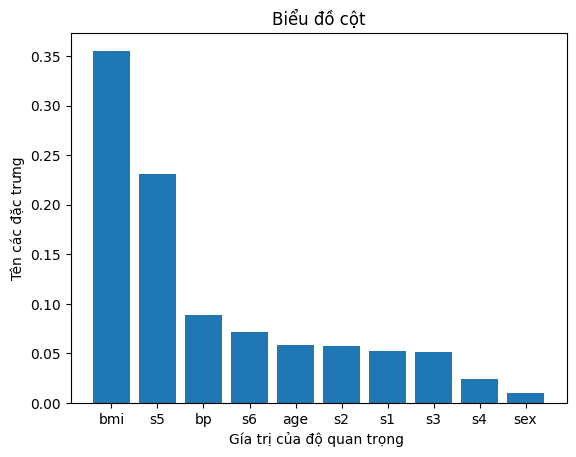

In [18]:
#6
import matplotlib.pyplot as plt
tam_quan_trong = mo_hinh.feature_importances_
abc = pd.DataFrame({"do_quan_trong":tam_quan_trong, "Dac_trung": du_lieu.feature_names})
abc = abc.sort_values(by="do_quan_trong", ascending= False)
plt.bar(abc["Dac_trung"], abc["do_quan_trong"])
plt.title("Biểu đồ cột")
plt.xlabel("Gía trị của độ quan trọng ")
plt.ylabel("Tên các đặc trưng")
plt.show()